In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("Online _Retail_Data.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
cancelaciones = df[df["InvoiceNo"].str.startswith("C", na=False)]
cancelaciones

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,01/12/2010 09:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,01/12/2010 09:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,01/12/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,01/12/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,01/12/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,09/12/2011 09:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,09/12/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,09/12/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,09/12/2011 11:58,1.25,17315.0,United Kingdom


In [8]:
# df sin pedidos cancelados
df_sincal = df[~df["InvoiceNo"].str.startswith("C", na=False)]
df_sincal

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09/12/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/2011 12:50,4.15,12680.0,France


In [9]:
print("Registros con quantity < 0: ", (df_sincal["Quantity"] < 0).sum())
print("Registros con UnitPrice < 0: ", (df["UnitPrice"] < 0).sum())

Registros con quantity < 0:  1336
Registros con UnitPrice < 0:  2


Quiero que mi modelo aprenda de ventas reales, por lo que decido quedarme con los df sin cancelaciones y limpiamos los Quantity y UnitPrice negativos.



In [10]:
df_sincal["Description"] = df_sincal["Description"].fillna("Sin descripción") # Rellena descripciones faltantes
df_sincal = df_sincal.dropna(subset=["CustomerID"]) # Borra los CustomerID invalidos
df_sincal = df_sincal[df_sincal["Quantity"] > 0] # Elimina Quantity negativas
df_sincal = df_sincal[df_sincal["UnitPrice"] > 0] # Elimina UnitPrice negativas o 0
df_sincal["InvoiceDate"]=pd.to_datetime(df_sincal["InvoiceDate"], dayfirst=True, errors="coerce")


df_sincal.isnull().sum()

C:\Users\luise\AppData\Local\Temp\ipykernel_19476\3706750312.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sincal["Description"] = df_sincal["Description"].fillna("Sin descripción") # Rellena descripciones faltantes


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Defino la columna de ingresos totales por venta

In [11]:
df_sincal["Income"] = df_sincal["UnitPrice"] * df_sincal["Quantity"]

df_sincal.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Income
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [12]:
ingresos_promedio = df_sincal["Income"].mean()
ingresos_totales = df_sincal["Income"].sum()


print(ingresos_totales)
print(ingresos_promedio)

8911407.904
22.396999889415003


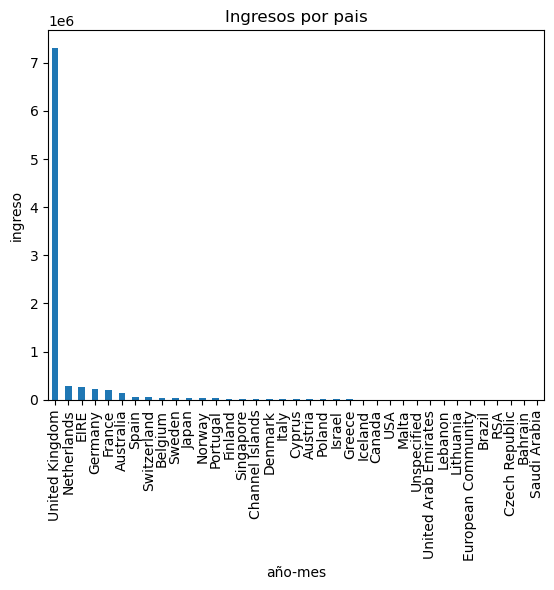

In [13]:
ingreso_por_pais = df_sincal.groupby("Country")["Income"].sum()

ingreso_por_pais.sort_values(ascending=False).plot(kind="bar")

plt.title("Ingresos por pais")
plt.xlabel("año-mes")
plt.ylabel("ingreso")

plt.show()

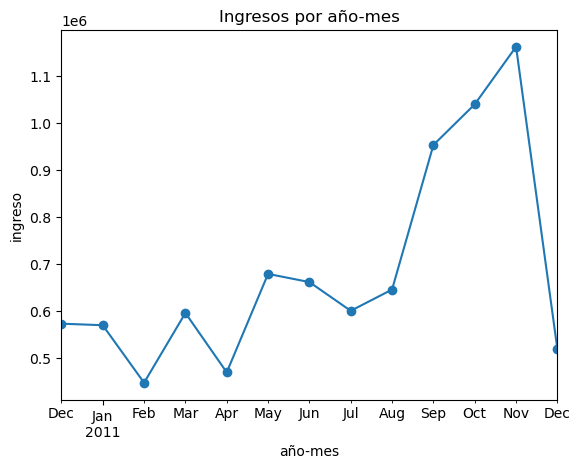

In [14]:
df_sincal["YearMonth"] = df_sincal["InvoiceDate"].dt.to_period("M")
ingreso_por_mes_año = df_sincal.groupby("YearMonth")["Income"].sum()

ingreso_por_mes_año.plot(kind="line", marker="o")

plt.title("Ingresos por año-mes")
plt.xlabel("año-mes")
plt.ylabel("ingreso")

plt.show()

TICKET PROMEDIO

In [16]:
ticket_promedio = df_sincal['Income'].sum() / df_sincal['InvoiceNo'].nunique()

print(ticket_promedio)

480.8659563997409


In [17]:
df["InvoiceNo"].nunique()

25900

Agrupamos por cliente el df

In [26]:
clientes = df_sincal.groupby("CustomerID").agg({
    "Income": ["sum", "mean"],
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "StockCode": "nunique",
    "Country": lambda x: x.mode()[0],
    "InvoiceDate": ["min", "max"]
})

clientes.columns = [
    "TotalGasto",
    "TicketPromedio",
    "NumCompras",
    "TotalProductos",
    "ProductosDistintos",
    "Pais",
    "PrimeraCompra",
    "UltimaCompra"
]

#Definimos el Recency
fecha_referencia = df_sincal["InvoiceDate"].max()

clientes["Recency"] = (
    fecha_referencia - clientes["UltimaCompra"]
).dt.days

clientes["AntiguedadCliente"] = (
    clientes["UltimaCompra"] - clientes["PrimeraCompra"]
).dt.days


clientes = clientes.reset_index()
clientes.head()

,CustomerID,TotalGasto,TicketPromedio,NumCompras,TotalProductos,ProductosDistintos,Pais,PrimeraCompra,UltimaCompra,Recency,AntiguedadCliente
0,12346.0,77183.60,77183.600000,1,74215,1,United Kingdom,2011-01-18 10:01:00,2011-01-18 10:01:00,325,0
1,12347.0,4310.00,23.681319,7,2458,103,Iceland,2010-12-07 14:57:00,2011-12-07 15:52:00,1,365
2,12348.0,1797.24,57.975484,4,2341,22,Finland,2010-12-16 19:09:00,2011-09-25 13:13:00,74,282
3,12349.0,1757.55,24.076027,1,631,73,Italy,2011-11-21 09:51:00,2011-11-21 09:51:00,18,0
4,12350.0,334.40,19.670588,1,197,17,Norway,2011-02-02 16:01:00,2011-02-02 16:01:00,309,0


In [39]:
clientes.describe()

,CustomerID,TotalGasto,TicketPromedio,NumCompras,TotalProductos,ProductosDistintos,PrimeraCompra,UltimaCompra,Recency,AntiguedadCliente,LogTotalGasto
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338,4338,4338.000000,4338.000000,4338.000000
mean,15300.408022,2054.266460,68.350506,4.272015,1191.289073,61.501153,2011-04-30 17:06:50.857538048,2011-09-08 11:38:59.045643008,91.536422,130.448594,6.593627
min,12346.000000,3.750000,2.101286,1.000000,1.000000,1.000000,2010-12-01 08:26:00,2010-12-01 09:53:00,0.000000,0.000000,1.558145
25%,13813.250000,307.415000,12.365367,1.000000,160.000000,16.000000,2011-01-17 11:13:15,2011-07-20 19:18:00,17.000000,0.000000,5.731446
50%,15299.500000,674.485000,17.723119,2.000000,379.000000,35.000000,2011-04-05 09:52:30,2011-10-20 10:40:30,50.000000,92.500000,6.515431
75%,16778.750000,1661.740000,24.858417,5.000000,992.750000,77.000000,2011-08-19 10:11:30,2011-11-22 11:05:45,141.000000,251.750000,7.416222
max,18287.000000,280206.020000,77183.600000,209.000000,196915.000000,1787.000000,2011-12-09 12:16:00,2011-12-09 12:50:00,373.000000,373.000000,12.543284
std,1721.808492,8989.230441,1467.918896,7.697998,5046.081546,85.366768,NaN,NaN,100.014169,132.039554,1.257578


In [40]:
clientes["TotalGasto"].skew()

19.32495323682082

Skew bastante grande. Para observar una grafica de distribución adecuada usamos una escala logaritmica.

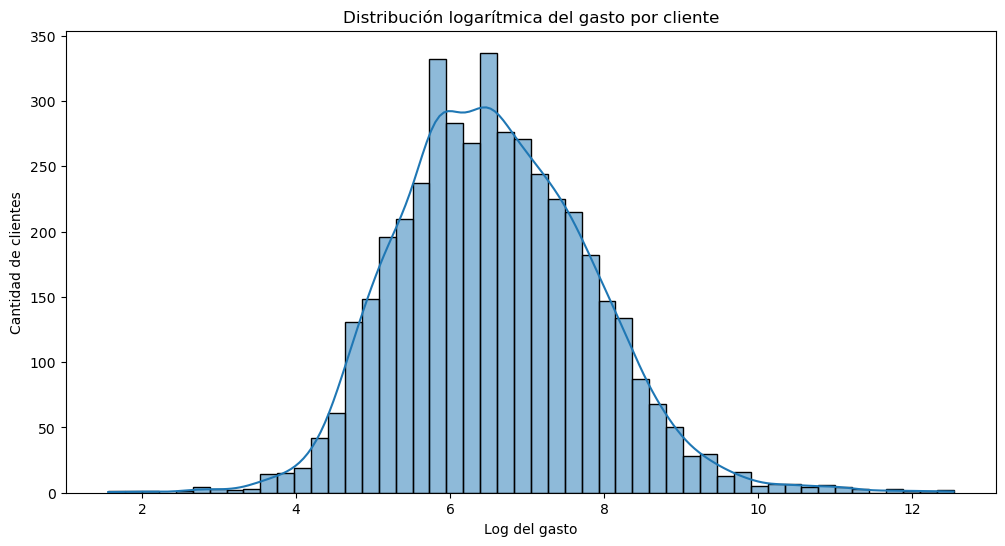

In [36]:
clientes["LogTotalGasto"] = np.log1p(clientes["TotalGasto"])

plt.figure(figsize=(12,6))

sns.histplot(
    data=clientes,
    x="LogTotalGasto",
    bins=50,
    kde=True
)

plt.title("Distribución logarítmica del gasto por cliente")
plt.xlabel("Log del gasto")
plt.ylabel("Cantidad de clientes")

plt.show()

Obtengo la matriz de correlación


In [41]:
corrmat = clientes.corr(numeric_only=True)
corrmat

,CustomerID,TotalGasto,TicketPromedio,NumCompras,TotalProductos,ProductosDistintos,Recency,AntiguedadCliente,LogTotalGasto
CustomerID,1.000000,-0.013691,-0.014020,-0.010971,-0.021039,-0.008358,0.007631,-0.006876,-0.092829
TotalGasto,-0.013691,1.000000,0.287264,0.553650,0.922907,0.386977,-0.122097,0.225735,0.443143
TicketPromedio,-0.014020,0.287264,1.000000,-0.005205,0.326191,-0.023467,0.024617,-0.010113,0.102561
NumCompras,-0.010971,0.553650,-0.005205,1.000000,0.558081,0.692223,-0.260578,0.476560,0.568741
TotalProductos,-0.021039,0.922907,0.326191,0.558081,1.000000,0.409977,-0.123758,0.228969,0.438771
ProductosDistintos,-0.008358,0.386977,-0.023467,0.692223,0.409977,1.000000,-0.300728,0.458102,0.580469
Recency,0.007631,-0.122097,0.024617,-0.260578,-0.123758,-0.300728,1.000000,-0.513562,-0.435101
AntiguedadCliente,-0.006876,0.225735,-0.010113,0.476560,0.228969,0.458102,-0.513562,1.000000,0.678849
LogTotalGasto,-0.092829,0.443143,0.102561,0.568741,0.438771,0.580469,-0.435101,0.678849,1.000000


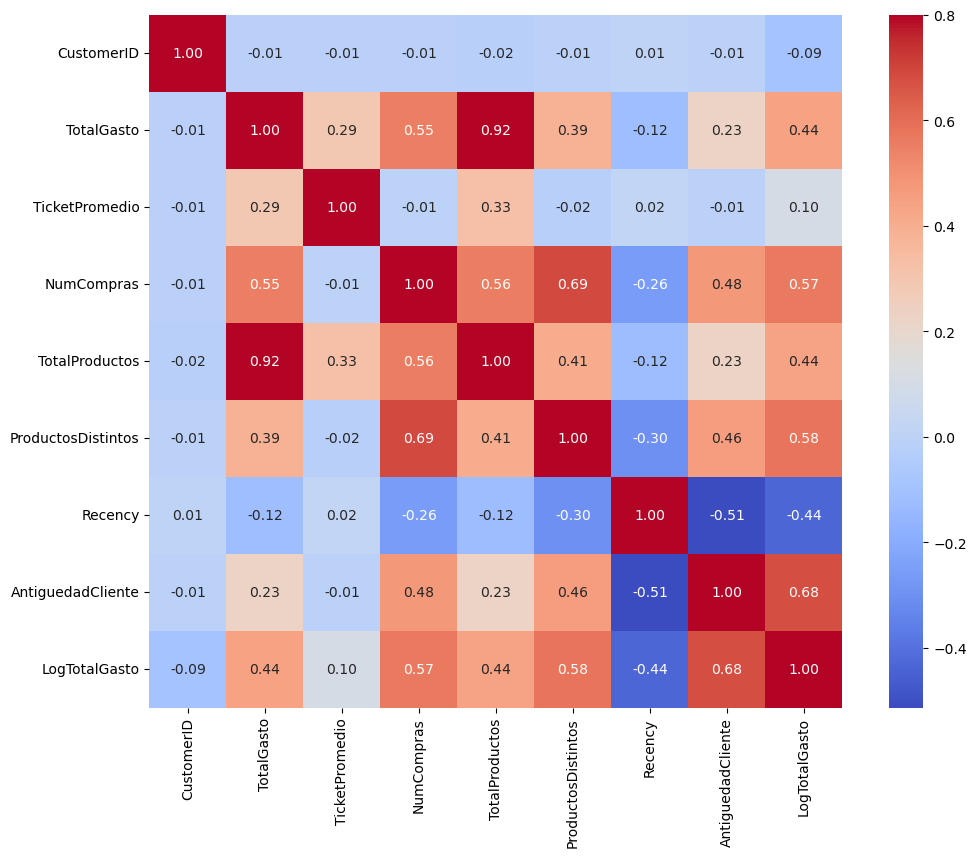

In [44]:
ax = plt.subplots(figsize = (12,9))
sns.heatmap(corrmat, vmax=0.8, square=True, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

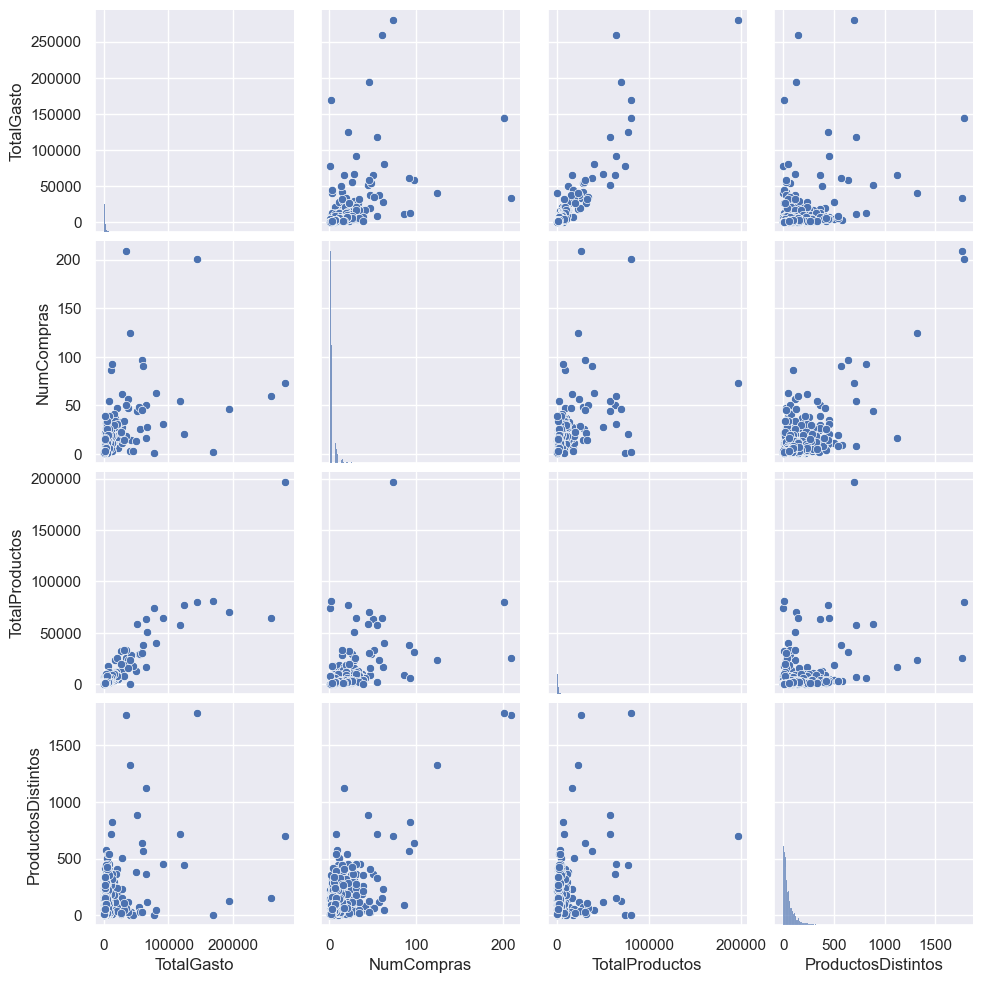

In [48]:
sns.set()
cols = ["TotalGasto", "NumCompras", "TotalProductos", "ProductosDistintos",]

sns.pairplot(clientes[cols], height=2.5)
plt.show()

Modelo de Regresión Lineal SIN escala logaritmica

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

y = clientes["TotalGasto"]

X = clientes[[
    "NumCompras",
    "TotalProductos",
    "ProductosDistintos",
    "Recency",
    "AntiguedadCliente"
]]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 731.3868243543108
RMSE: 5757.672047541864
R2: 0.6763971983940386


Modelo de Regresión Lineal CON escala logaritmica

In [71]:
y = clientes["LogTotalGasto"]

X = clientes[[
    "NumCompras",
    "TotalProductos",
    "ProductosDistintos",
    "Recency",
    "AntiguedadCliente"
]]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.6045978778836678
RMSE: 0.778801720650162
R2: 0.6216722197657276


RandomForest

In [65]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2 = r2_score(y_test, y_pred_rf)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 769.0167368894008
RMSE: 5814.36499164064
R2: 0.6699931109941846
